## Regression Model

In [1]:
import tensorflow as tf
print(tf.__version__) # check the version (should be 2.x+)

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

2.21.0
Notebook last run (end-to-end): 2026-10-07 21:49:24.666566


## Making a new Data Set

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Make a bigger dataset
X = np.arange(-200, 200, 4)
X

array([-200, -196, -192, -188, -184, -180, -176, -172, -168, -164, -160,
       -156, -152, -148, -144, -140, -136, -132, -128, -124, -120, -116,
       -112, -108, -104, -100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,
        -68,  -64,  -60,  -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,
        -24,  -20,  -16,  -12,   -8,   -4,    0,    4,    8,   12,   16,
         20,   24,   28,   32,   36,   40,   44,   48,   52,   56,   60,
         64,   68,   72,   76,   80,   84,   88,   92,   96,  100,  104,
        108,  112,  116,  120,  124,  128,  132,  136,  140,  144,  148,
        152,  156,  160,  164,  168,  172,  176,  180,  184,  188,  192,
        196])

In [4]:
# Make labels for the dataset (adhering to the same pattern as before)
y = np.arange(-180, 220, 4)
y

array([-180, -176, -172, -168, -164, -160, -156, -152, -148, -144, -140,
       -136, -132, -128, -124, -120, -116, -112, -108, -104, -100,  -96,
        -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,
        -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,
         -4,    0,    4,    8,   12,   16,   20,   24,   28,   32,   36,
         40,   44,   48,   52,   56,   60,   64,   68,   72,   76,   80,
         84,   88,   92,   96,  100,  104,  108,  112,  116,  120,  124,
        128,  132,  136,  140,  144,  148,  152,  156,  160,  164,  168,
        172,  176,  180,  184,  188,  192,  196,  200,  204,  208,  212,
        216])

In [5]:
# Same result as above
y = X + 20
y

array([-180, -176, -172, -168, -164, -160, -156, -152, -148, -144, -140,
       -136, -132, -128, -124, -120, -116, -112, -108, -104, -100,  -96,
        -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,  -56,  -52,
        -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,  -12,   -8,
         -4,    0,    4,    8,   12,   16,   20,   24,   28,   32,   36,
         40,   44,   48,   52,   56,   60,   64,   68,   72,   76,   80,
         84,   88,   92,   96,  100,  104,  108,  112,  116,  120,  124,
        128,  132,  136,  140,  144,  148,  152,  156,  160,  164,  168,
        172,  176,  180,  184,  188,  192,  196,  200,  204,  208,  212,
        216])

## Splitting data into training and test sets


In [6]:
len(X)

100

In [8]:
# Split data into train and test sets
X_train = X[:80] # first 40 examples (80% of data)
y_train = y[:80]

X_test = X[80:] # last 10 examples (20% of data)
y_test = y[80:]

len(X_train), len(X_test)

X_train, X_test

(array([-200, -196, -192, -188, -184, -180, -176, -172, -168, -164, -160,
        -156, -152, -148, -144, -140, -136, -132, -128, -124, -120, -116,
        -112, -108, -104, -100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,
         -68,  -64,  -60,  -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,
         -24,  -20,  -16,  -12,   -8,   -4,    0,    4,    8,   12,   16,
          20,   24,   28,   32,   36,   40,   44,   48,   52,   56,   60,
          64,   68,   72,   76,   80,   84,   88,   92,   96,  100,  104,
         108,  112,  116]),
 array([120, 124, 128, 132, 136, 140, 144, 148, 152, 156, 160, 164, 168,
        172, 176, 180, 184, 188, 192, 196]))

## Visualizing the Data

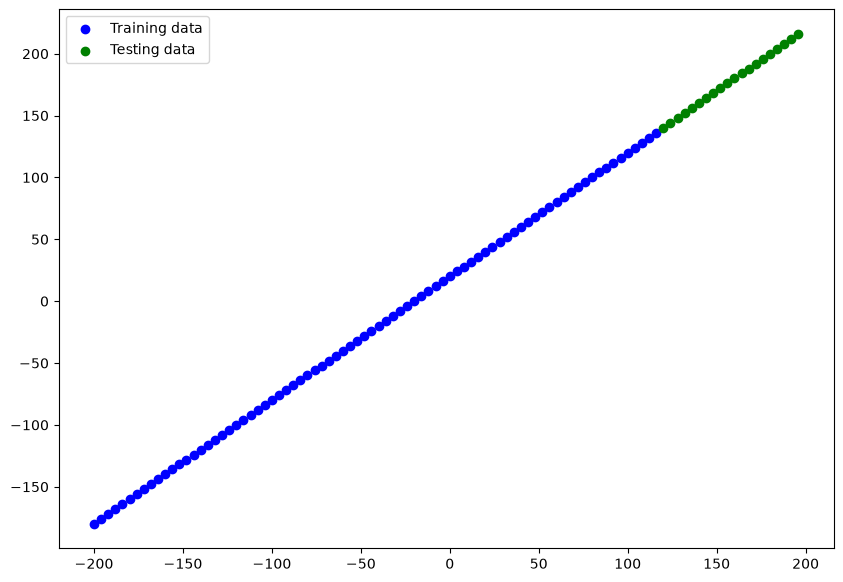

In [9]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c='b', label='Training data')
# Plot test data in green
plt.scatter(X_test, y_test, c='g', label='Testing data')
# Show the legend
plt.legend();

In [10]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# Fit model (same as above)
#model.fit(X_train, y_train, epochs=100) # commented out on purpose (not fitting it just yet)

## Summary of Model

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Testing with Input Shape

In [12]:
# Set random seed
tf.random.set_seed(42)

# Create a model (same as above)
model = tf.keras.Sequential([
  tf.keras.layers.Input(shape=[1]),
  tf.keras.layers.Dense(5, activation='relu'),
  tf.keras.layers.Dense(1) # define the input_shape to our model
])

# Compile model (same as above)
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 5)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

## Fiting the model with training data

In [14]:
# Fit the model to the training data
model.fit(X_train, y_train, epochs=100, verbose=1) # verbose controls how much gets output

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 91.6989 - mae: 91.6989
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 43.4403 - mae: 43.4403
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 35.2027 - mae: 35.2027
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 35.2815 - mae: 35.2815 
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 32.6413 - mae: 32.6413
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 32.1632 - mae: 32.1632
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 40.5002 - mae: 40.5002 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 38.8891 - mae: 38.8891 
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 33.5669 - mae: 33.5669 
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 33.3083 - mae: 33.3083
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 32.8705 - mae: 32.8705
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 43.9568 - mae: 43.9568
Epoch 13/100
3/3 ━━━━

## Check Summary 

In [15]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 5)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18 (76.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [18]:
from tensorflow.keras.utils import plot_model

plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


## Visualize the predictions

In [19]:
y_preds = model.predict(X_test)

y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


array([[166.50223],
       [172.03183],
       [177.56139],
       [183.09097],
       [188.62057],
       [194.15016],
       [199.67975],
       [205.20935],
       [210.73892],
       [216.26851],
       [221.79811],
       [227.3277 ],
       [232.85728],
       [238.38689],
       [243.91646],
       [249.44604],
       [254.97565],
       [260.50525],
       [266.03482],
       [271.56442]], dtype=float32)

## Plotting functions

In [20]:
def plot_predictions(train_data=X_train, 
                     train_labels=y_train, 
                     test_data=X_test, 
                     test_labels=y_test, 
                     predictions=y_preds):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))
  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", label="Training data")
  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", label="Testing data")
  # Plot the predictions in red (predictions were made on the test data)
  plt.scatter(test_data, predictions, c="r", label="Predictions")
  # Show the legend
  plt.legend();

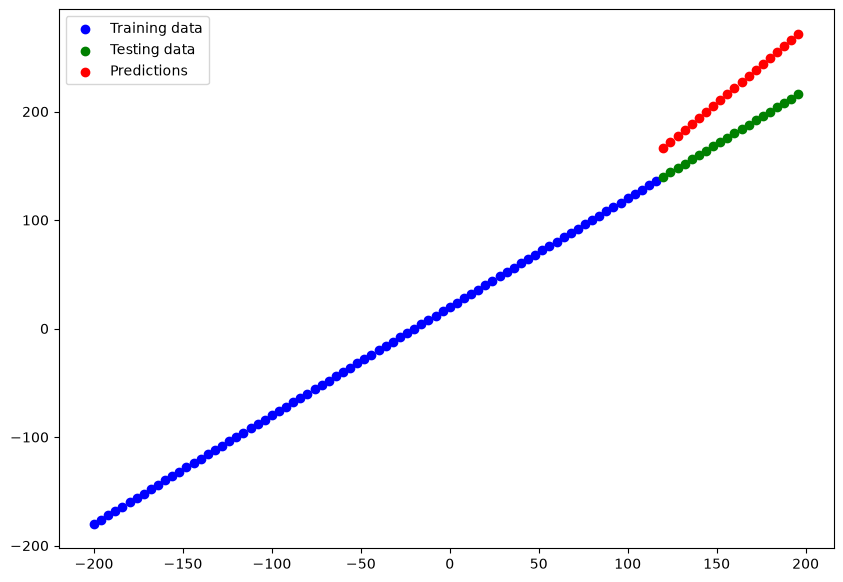

In [21]:
plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_preds)

## Getting model metrics

In [22]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - loss: 41.0333 - mae: 41.0333


[41.03331756591797, 41.03331756591797]

In [23]:
# Calculate the mean absolute error
tf.metrics.mae(y_true=y_test, y_pred=y_preds)

# tf.metrics.mean_absolute_error into mae since its integrated 
# in newer version of Keras 


<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([26.502228, 28.03183 , 29.561386, 31.090973, 32.620575, 34.15016 ,
       35.67975 , 37.20935 , 38.738922, 40.26851 , 41.79811 , 43.327698,
       44.857285, 46.386887, 47.91646 , 49.446045, 50.975647, 52.50525 ,
       54.03482 , 55.564423], dtype=float32)>

In [24]:
y_test, y_preds

(array([140, 144, 148, 152, 156, 160, 164, 168, 172, 176, 180, 184, 188,
        192, 196, 200, 204, 208, 212, 216]),
 array([[166.50223],
        [172.03183],
        [177.56139],
        [183.09097],
        [188.62057],
        [194.15016],
        [199.67975],
        [205.20935],
        [210.73892],
        [216.26851],
        [221.79811],
        [227.3277 ],
        [232.85728],
        [238.38689],
        [243.91646],
        [249.44604],
        [254.97565],
        [260.50525],
        [266.03482],
        [271.56442]], dtype=float32))

In [25]:
# Check the tensor shapes
y_test.shape, y_preds.shape

((20,), (20, 1))

In [26]:
y_preds.squeeze().shape

(20,)

In [27]:
# What do they look like?
y_test, y_preds.squeeze()

(array([140, 144, 148, 152, 156, 160, 164, 168, 172, 176, 180, 184, 188,
        192, 196, 200, 204, 208, 212, 216]),
 array([166.50223, 172.03183, 177.56139, 183.09097, 188.62057, 194.15016,
        199.67975, 205.20935, 210.73892, 216.26851, 221.79811, 227.3277 ,
        232.85728, 238.38689, 243.91646, 249.44604, 254.97565, 260.50525,
        266.03482, 271.56442], dtype=float32))

## Testing eval metrics

In [28]:
# Calcuate the MAE
tf.metrics.mae(y_true=y_test, 
               y_pred=y_preds.squeeze()) # use squeeze() to make same shape


<tf.Tensor: shape=(), dtype=float32, numpy=41.03331756591797>

In [29]:
# Calculate the MSE using pure TensorFlow math
mse = tf.reduce_mean(tf.square(y_test - y_preds.squeeze()))
mse

<tf.Tensor: shape=(), dtype=float64, numpy=1761.526097691746>

In [30]:
def mae(y_test, y_pred):
  """
  Calculuates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.mean_absolute_error(y_test,
                                        y_pred)
  
def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  return tf.metrics.mean_squared_error(y_test,
                                       y_pred)

## Building New Models

## Model No.1

In [31]:
# Set random seed
tf.random.set_seed(42)

# Replicate original model
model_1 = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=['mae'])

# Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 46.9382 - mae: 46.9382
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 34.7322 - mae: 34.7322
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 34.8435 - mae: 34.8435
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 34.5982 - mae: 34.5982
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 34.6690 - mae: 34.6690
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 34.7476 - mae: 34.7476
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 34.5350 - mae: 34.5350 
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 34.6059 - mae: 34.6059
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 34.6768 - mae: 34.6768
Epoch 10/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 34.8159 - mae: 34.8159
Epoch 11/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 34.5428 - mae: 34.5428 
Epoch 12/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 34.6137 - mae: 34.6137
Epoch 13/100
3/3 ━━━━━━

## Visuals of model no.1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step


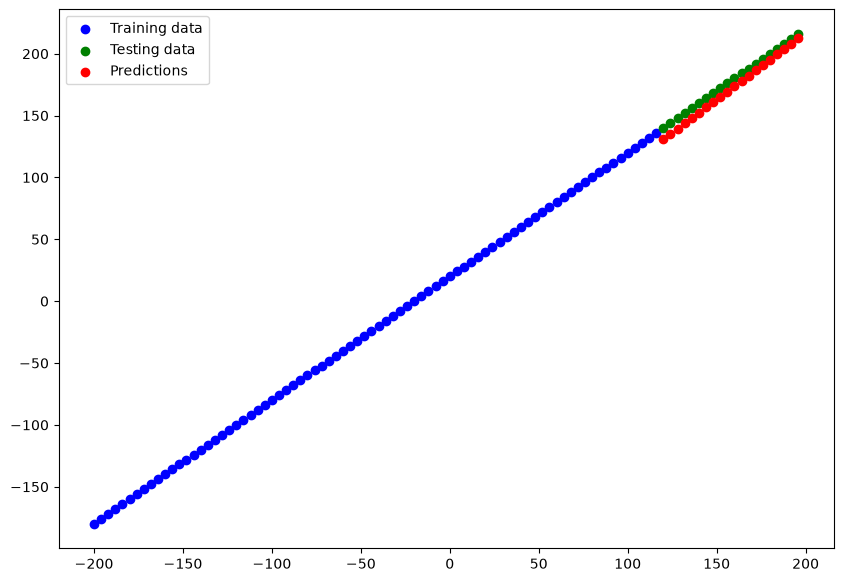

In [32]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

## Fix for Calculation of mse & mae

In [33]:
def mae(y_test, y_pred):
  """
  Calculates mean absolute error between y_test and y_preds.
  """
  return tf.metrics.mae(y_test, y_pred)
  
def mse(y_test, y_pred):
  """
  Calculates mean squared error between y_test and y_preds.
  """
  # Using the built-in shortened alias
  return tf.metrics.mse(y_test, y_pred)

  # ALternatively, if the above still gives version issues, use pure TF math:
  # return tf.reduce_mean(tf.square(y_test - y_pred))

In [34]:
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(6.437018), np.float32(44.30239))

## Making model no. 2

In [ ]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_1, add an extra layer and set first layer to have 100 hidden units
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), #set hidden units to 100
  tf.keras.layers.Dense(1) # add a second layer
])

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), # change optimizer to Adam with a learning rate of 0.001
                metrics=['mae'])

# Fit the model
model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0) # set verbose to 0 for less output

## Visuals of model no.2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


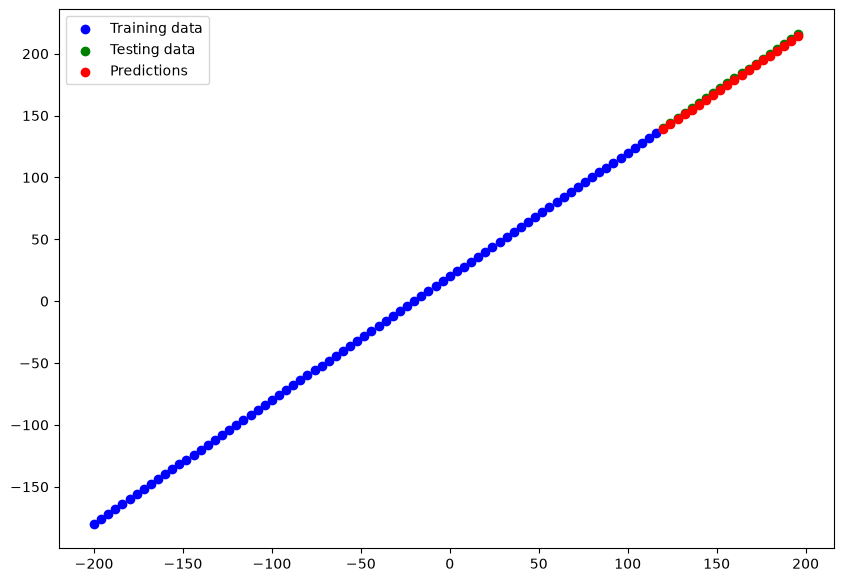

In [36]:
# Make and plot predictions for model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [37]:
# Calculate model_2 metrics
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(1.2965645), np.float32(1.7168621))

## Making model no. 3

In [38]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_2 and add an extra layer with 100 hidden units
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100), #adds second layer with 100 hidden units
  tf.keras.layers.Dense(1)
])

# Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['mae'])

# Fit the model
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


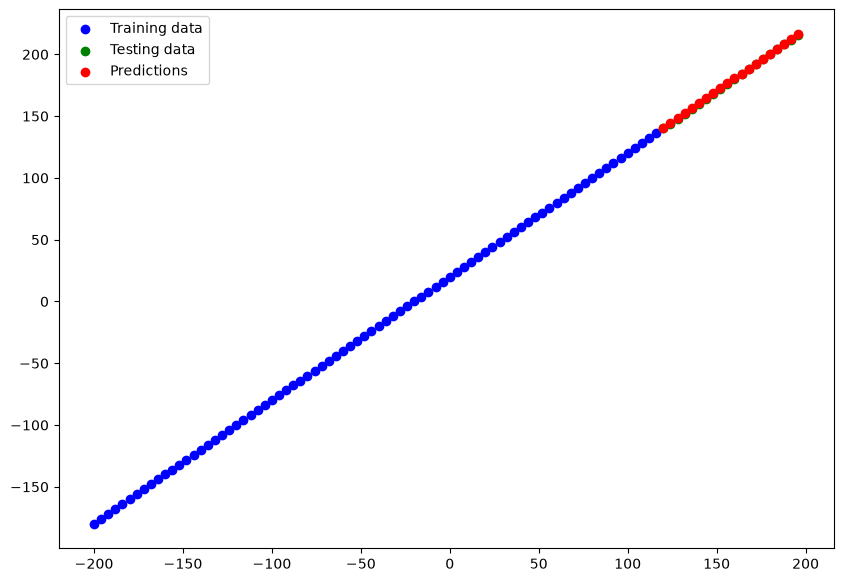

In [39]:
# Make and plot predictions for model_3
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [40]:
# Calculate model_3 metrics
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(np.float32(0.45003587), np.float32(0.20681004))

## Making model no. 4

In [41]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_3
model_4 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_4.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), #set learning rate to 0.0001
                metrics=['mae'])

# Fit the model
model_4.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step


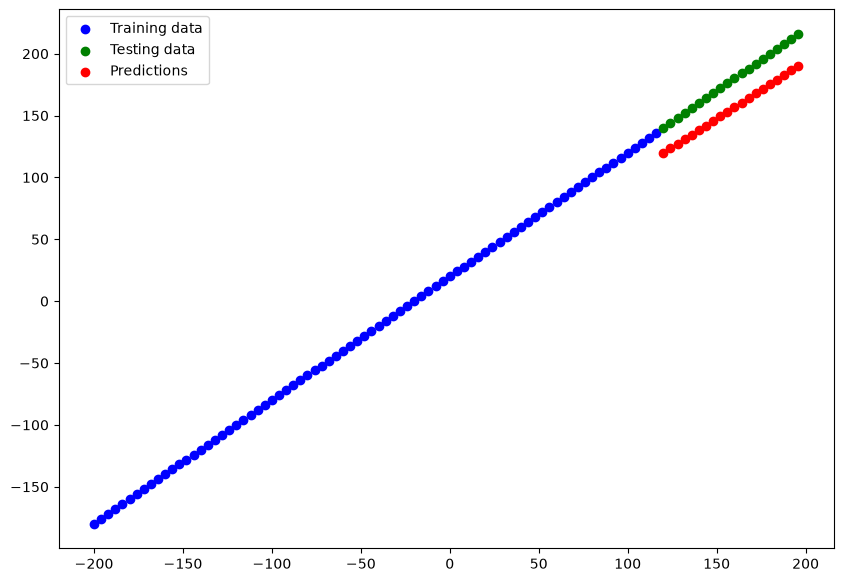

In [42]:
# Make and plot predictions for model_4
y_preds_4 = model_4.predict(X_test)
plot_predictions(predictions=y_preds_4)

In [43]:
# Calculate model_4 metrics
mae_4 = mae(y_test, y_preds_4.squeeze()).numpy()
mse_4 = mse(y_test, y_preds_4.squeeze()).numpy()
mae_4, mse_4

(np.float32(23.06998), np.float32(534.9774))

## Making model no. 5

In [44]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_3
model_5 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_5.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #set learning rate to 0.001
                metrics=['mae'])

# Fit the model
model_5.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step


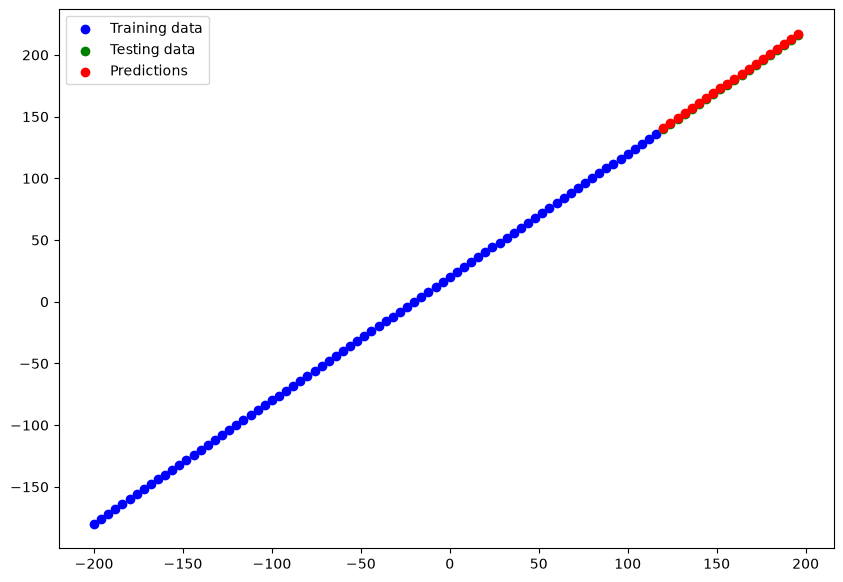

In [45]:
# Make and plot predictions for model_5
y_preds_5 = model_5.predict(X_test)
plot_predictions(predictions=y_preds_5)

In [46]:
# Calculate model_5 metrics
mae_5 = mae(y_test, y_preds_5.squeeze()).numpy()
mse_5 = mse(y_test, y_preds_5.squeeze()).numpy()
mae_5, mse_5

(np.float32(0.8456047), np.float32(0.7305636))

## Making model no. 6

In [47]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_3
model_6 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_6.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), #set learning rate to 0.0001
                metrics=['mae'])

# Fit the model
model_6.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.6

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step


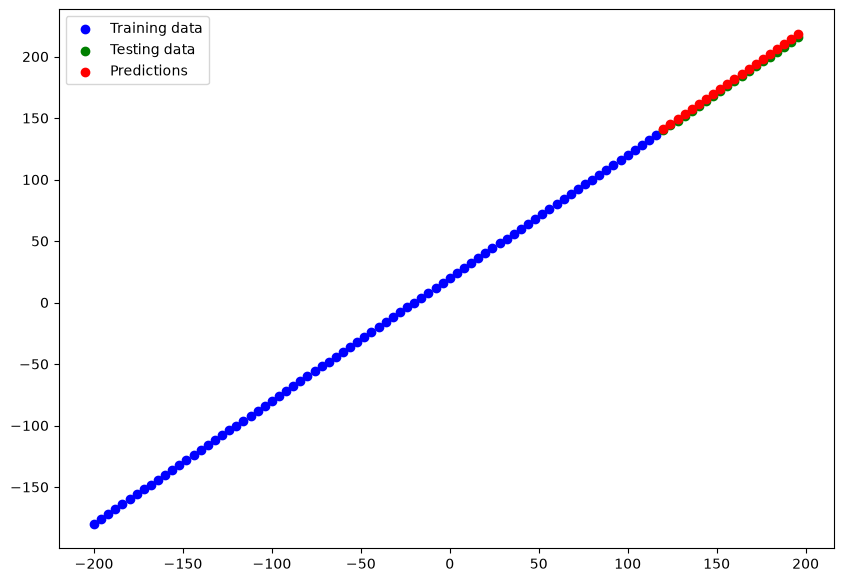

In [48]:
# Make and plot predictions for model_6
y_preds_6 = model_6.predict(X_test)
plot_predictions(predictions=y_preds_6)

In [49]:
# Calculate model_6 metrics
mae_6 = mae(y_test, y_preds_6.squeeze()).numpy()
mse_6 = mse(y_test, y_preds_6.squeeze()).numpy()
mae_6, mse_6

(np.float32(1.9661682), np.float32(3.9494014))

## Making model no. 7

In [50]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_6
model_7 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_7.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), #set learning rate to 0.001
                metrics=['mae'])

# Fit the model
model_7.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.7

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


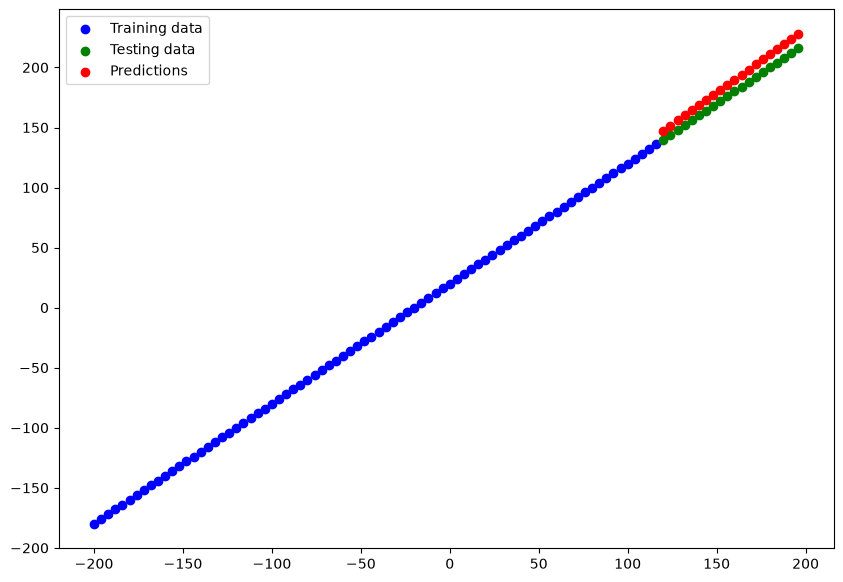

In [51]:
# Make and plot predictions for model_7
y_preds_7 = model_7.predict(X_test)
plot_predictions(predictions=y_preds_7)

In [52]:
# Calculate model_7 metrics
mae_7 = mae(y_test, y_preds_7.squeeze()).numpy()
mse_7 = mse(y_test, y_preds_7.squeeze()).numpy()
mae_7, mse_7

(np.float32(9.676714), np.float32(95.52132))

## Making model no. 8

In [53]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_5
model_8 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_8.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['mae'])

# Fit the model
model_8.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


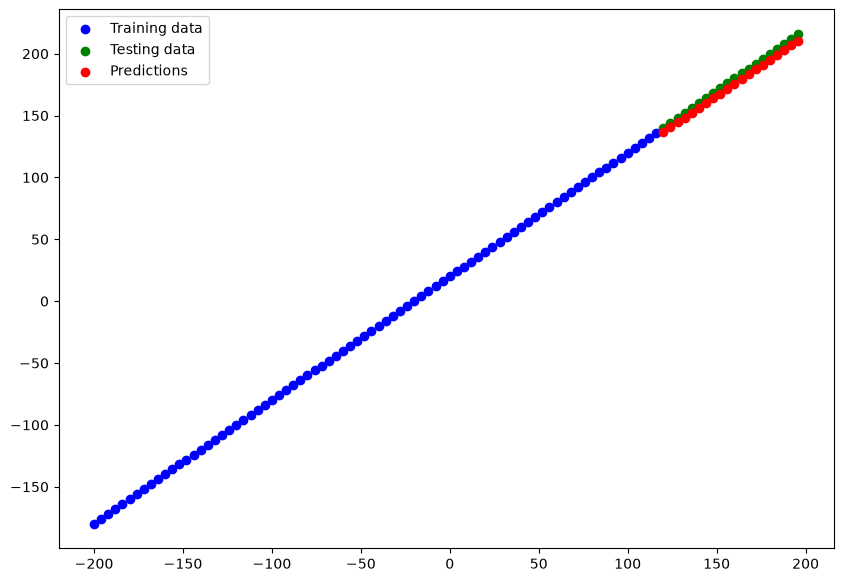

In [54]:
# Make and plot predictions for model_8
y_preds_8 = model_8.predict(X_test)
plot_predictions(predictions=y_preds_8)

In [55]:
# Calculate model_8 metrics
mae_8 = mae(y_test, y_preds_8.squeeze()).numpy()
mse_8 = mse(y_test, y_preds_8.squeeze()).numpy()
mae_8, mse_8

(np.float32(4.3573256), np.float32(19.38425))

## Rerun model no. 8

In [56]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_5
model_8 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_8.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['mae'])

# Fit the model
model_8.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500, verbose=0)

## Visuals of model no.8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


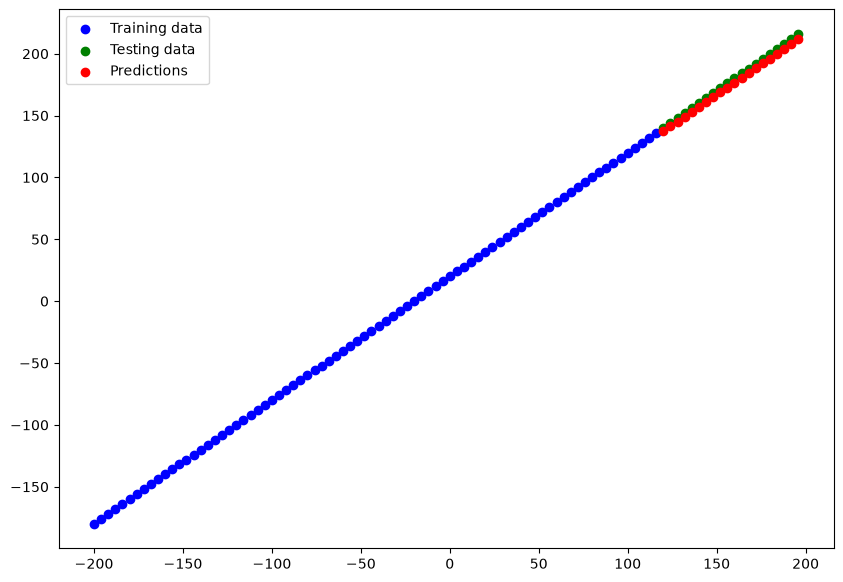

In [57]:
# Make and plot predictions for model_8
y_preds_8 = model_8.predict(X_test)
plot_predictions(predictions=y_preds_8)

In [58]:
# Calculate model_8 metrics
mae_8 = mae(y_test, y_preds_8.squeeze()).numpy()
mse_8 = mse(y_test, y_preds_8.squeeze()).numpy()
mae_8, mse_8

(np.float32(3.4524384), np.float32(12.165149))

## Rerun model no. 8 with more epochs

In [59]:
# Set random seed
tf.random.set_seed(42)

# Replicate model_5
model_8 = tf.keras.Sequential([
  tf.keras.layers.Dense(100), 
  tf.keras.layers.Dense(100),
  tf.keras.layers.Dense(1)
])

# Compile the model
model_8.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=['mae'])

# Fit the model
model_8.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=750, verbose=0)

## Visuals of model no.8

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


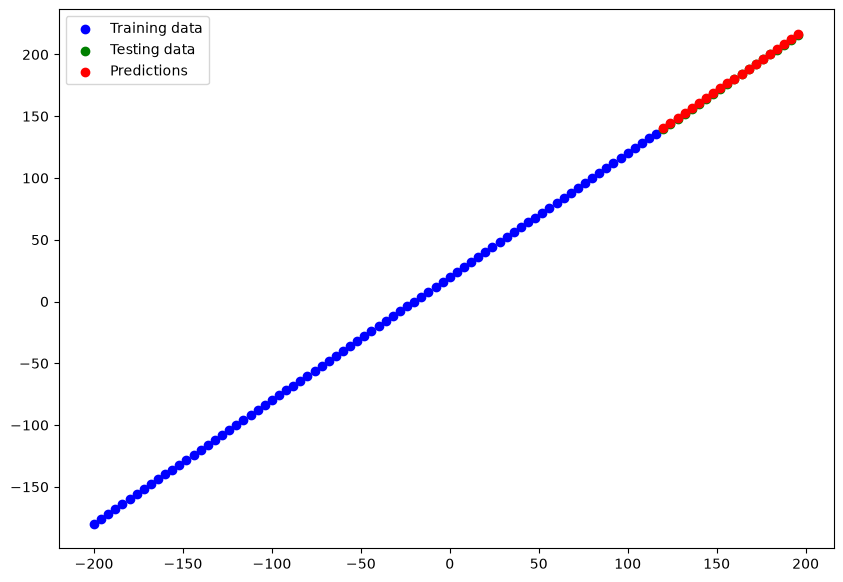

In [60]:
# Make and plot predictions for model_8
y_preds_8 = model_8.predict(X_test)
plot_predictions(predictions=y_preds_8)

In [61]:
# Calculate model_8 metrics
mae_8 = mae(y_test, y_preds_8.squeeze()).numpy()
mse_8 = mse(y_test, y_preds_8.squeeze()).numpy()
mae_8, mse_8

(np.float32(0.5200302), np.float32(0.27660736))